In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/used_cars.csv")
# Number of rows and columns (4009 rows and 12 column)
print(df.shape)

# Column names and data types
print(df.info())

# First 5 rows
df.head()

(4009, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB
None


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [5]:
# Count missing values in each column
print(df.isnull().sum())

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64



Null values per column:
 brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64


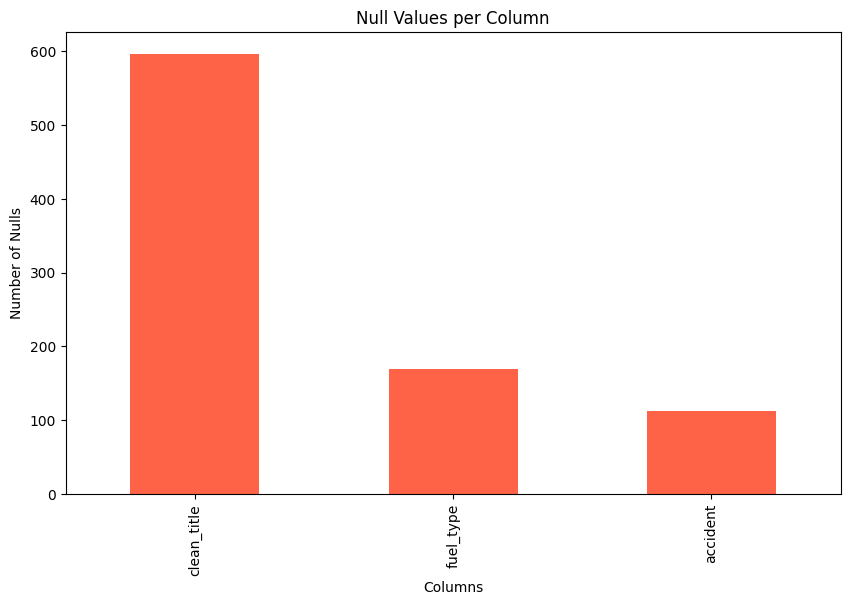

In [6]:
# Count of null values per column
null_counts = df.isnull().sum()
print("\nNull values per column:\n", null_counts)

# Optional: Bar plot of number of nulls
plt.figure(figsize=(10, 6))
null_counts[null_counts > 0].sort_values(ascending=False).plot(kind='bar', color='tomato')
plt.title("Null Values per Column")
plt.ylabel("Number of Nulls")
plt.xlabel("Columns")
plt.show()

In [7]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [8]:
# Example: brand distribution
print(df['brand'].value_counts())
print("\n")
# Fuel type distribution
print(df['fuel_type'].value_counts())
print("\n")
# clean title distribution
print(df['clean_title'].value_counts())
print("\n")
# transmission distribution
print(df['transmission'].value_counts())
print("\n")
# accident distribution
print(df['accident'].value_counts())



brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land             130
Nissan           116
Cadillac         107
GMC               91
RAM               91
Dodge             90
Tesla             87
Kia               76
Hyundai           72
Subaru            64
Acura             64
Mazda             64
Honda             63
INFINITI          59
Volkswagen        59
Lincoln           52
Jaguar            47
Volvo             38
Maserati          34
Bentley           33
MINI              33
Buick             30
Chrysler          28
Lamborghini       26
Genesis           20
Mitsubishi        20
Alfa              19
Rivian            17
Hummer            16
Pontiac           15
Ferrari           12
Rolls-Royce       11
Aston              9
Scion              6
McLaren            6
Saturn             5
FIAT               5
Lotus              4
Lucid  

In [9]:
#fill null values

df['fuel_type'] = df['fuel_type'].fillna("unknown")
df['accident'] = df['accident'].fillna("None reported")
df['clean_title'] = df['clean_title'].fillna("No")

In [10]:
df.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

In [11]:
# make price and milage in int values instead string to be easy afterwards to compare

df['price'] = (
    df['price']
    .astype(str)
    .str.replace(',', '')
    .str.replace('€', '')
    .str.replace('$', '')
    .astype(float)
)

df['price'] = df['price'].astype(int)

df['milage'] = (
    df['milage']
    .astype(str)
    .str.replace(',', '')
    .str.replace('mi.', '')
    .astype(float)
)

df['milage'] = df['milage'].astype(int)

df.head()



,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,No,54598
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,No,34999


In [12]:
import numpy as np

#let only Automatic and Manual as transmission types

def clean_transmission(x):
    if pd.isnull(x):
        return "Unknown"
    x = x.lower()
    if "auto" in x or "a/t" in x or "automatic" in x or "w/dual" in x:
        return "Automatic"
    elif "manual" in x or "m/t" in x or "mt" in x:
        return "Manual"
    else:
        return "Unknown"

df['transmission'] = df['transmission'].apply(clean_transmission)

In [13]:
df['transmission'].value_counts()

transmission
Automatic    3547
Manual        374
Unknown        88
Name: count, dtype: int64

In [14]:
# fuel type should be only Petrol, Diesel or Hybrid

def clean_fuel_type(x):
    if pd.isnull(x) or x.strip() in ["–", "not supported"]:
        return "Unknown"
    x = str(x).lower()
    if "gasoline" in x or "e85" in x:
        return "Petrol"
    elif "diesel" in x:
        return "Diesel"
    elif "hybrid" in x:
        return "Hybrid"
    elif "plug-in hybrid" in x:
        return "Hybrid"
    else:
        return "Unknown"

df['fuel_type'] = df['fuel_type'].apply(clean_fuel_type)
df['fuel_type'].value_counts()

fuel_type
Petrol     3448
Hybrid      228
Unknown     217
Diesel      116
Name: count, dtype: int64

In [15]:

# Create a binary column for accident

def clean_accident(x):
    if pd.isnull(x) or str(x).strip().lower() in ["unknown", "no", "none", "none reported"]:
        return 0
    else:
        return 1

df['accident'] = df['accident'].apply(clean_accident)

df["accident"].value_counts()

accident
0    3023
1     986
Name: count, dtype: int64

In [16]:
# add description column , this will help us to compare the input query with each car description

df['description'] = (
    df['brand'] + " " +
    df['model'] + " " +
    df['fuel_type'] + " " +
    df['engine'] + " " +
    "Interior color: " +  df['int_col'] + " " +
    "exterior color: " +  df['ext_col'] + " " +
    df['transmission'] + " car " +
    df['model_year'].astype(str)
)
df[['brand','model','fuel_type','transmission','model_year','description']].head()

,brand,model,fuel_type,transmission,model_year,description
0,Ford,Utility Police Interceptor Base,Petrol,Automatic,2013,Ford Utility Police Interceptor Base Petrol 30...
1,Hyundai,Palisade SEL,Petrol,Automatic,2021,Hyundai Palisade SEL Petrol 3.8L V6 24V GDI DO...
2,Lexus,RX 350 RX 350,Petrol,Automatic,2022,Lexus RX 350 RX 350 Petrol 3.5 Liter DOHC Inte...
3,INFINITI,Q50 Hybrid Sport,Hybrid,Automatic,2015,INFINITI Q50 Hybrid Sport Hybrid 354.0HP 3.5L ...
4,Audi,Q3 45 S line Premium Plus,Petrol,Automatic,2021,Audi Q3 45 S line Premium Plus Petrol 2.0L I4 ...


In [ ]:
# save the clean dataset to a new csv file

df.to_csv("data/clean_cars.csv", index=False)

print("Clean dataset saved as clean_cars.csv")

C:\Users\mirela.ciuca\AppData\Local\Temp\ipykernel_31968\3101244282.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='fuel_type', y='price', data=df, estimator=np.mean, palette='Set2')


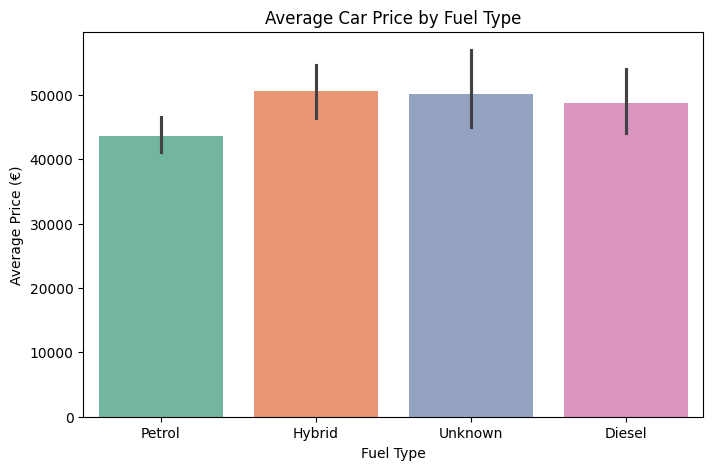

In [17]:
# show a price graphic based on fuel types

plt.figure(figsize=(8,5))
sns.barplot(x='fuel_type', y='price', data=df, estimator=np.mean, palette='Set2')
plt.title("Average Car Price by Fuel Type")
plt.ylabel("Average Price (€)")
plt.xlabel("Fuel Type")
plt.show()

C:\Users\mirela.ciuca\AppData\Local\Temp\ipykernel_31968\1165736523.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='accident', data=df, palette='Set1')


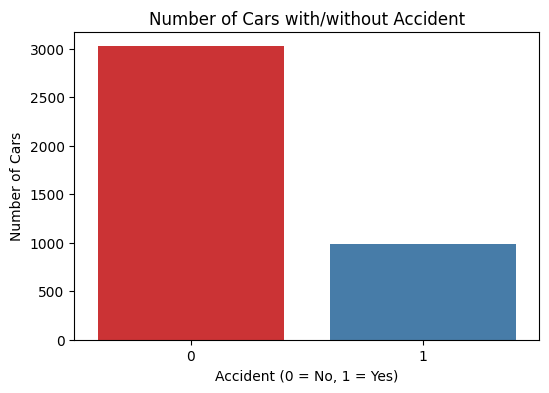

In [18]:
# show a graphic to see how many cars are with/without an accident

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='accident', data=df, palette='Set1')
plt.title("Number of Cars with/without Accident")
plt.xlabel("Accident (0 = No, 1 = Yes)")
plt.ylabel("Number of Cars")
plt.show()

C:\Users\mirela.ciuca\AppData\Local\Temp\ipykernel_31968\1867212457.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='accident', y='price', data=df[df['price']<=200000], palette='Set2')


2000 2954083


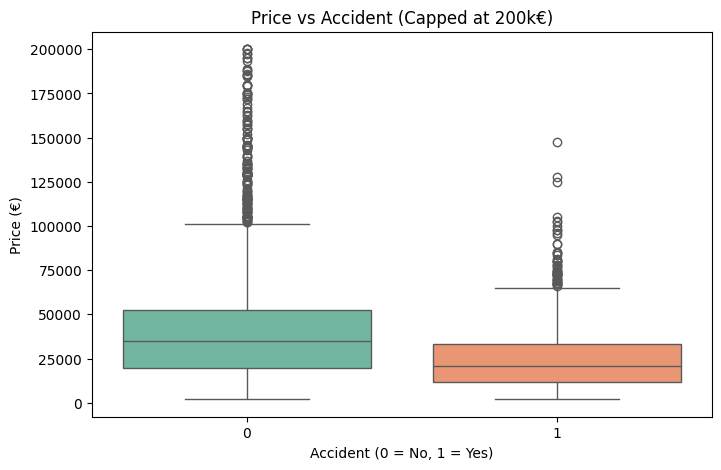

In [19]:
# show a graphic to see the prices of cars if there was an accident or not

import matplotlib.pyplot as plt
import seaborn as sns
print(df['price'].min(), df['price'].max())


plt.figure(figsize=(8,5))
sns.boxplot(x='accident', y='price', data=df[df['price']<=200000], palette='Set2')
plt.title("Price vs Accident (Capped at 200k€)")
plt.xlabel("Accident (0 = No, 1 = Yes)")
plt.ylabel("Price (€)")
plt.show()

C:\Users\mirela.ciuca\AppData\Local\Temp\ipykernel_31968\3459835131.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fuel_type', y='price', data=df[df['price']<=200000], palette='Set2')


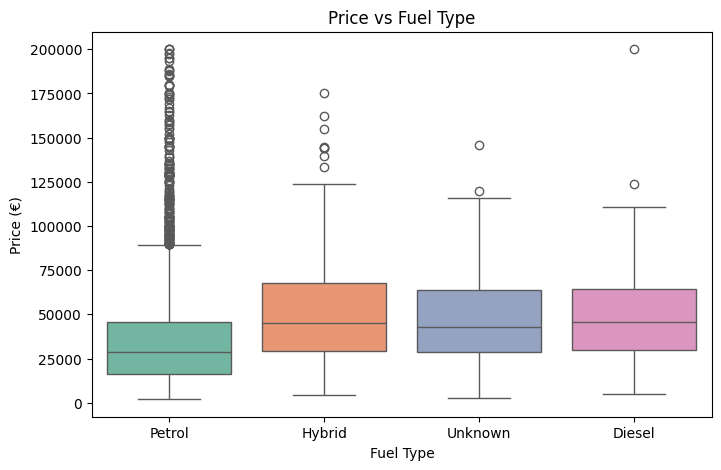

In [20]:
# show a boxplot to see the outliers

plt.figure(figsize=(8,5))
sns.boxplot(x='fuel_type', y='price', data=df[df['price']<=200000], palette='Set2')
plt.title("Price vs Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Price (€)")
plt.show()